## Oppgave 1: Visualiser data i et statisk kart (5 poeng)

Lag et *statisk* tematisk kart ved å bruke ferdighetene du lærte i forelesningen. Kartet skal inneholde mer enn ett lag (fra minst to forskjellige datasett). Vær oppmerksom på klassifisering og visualisering (valg av passende fargeskjema, etc.). Skriv koden din i denne notatboken, og lagre de resulterende kartene i `.png`-format i `NOTEBOOK_MAPPE / "output"`-mappen.

### Tema for kartet

- Bruk et hvilket som helst av datasettene vi har brukt i løpet av emnet (f.eks. befolkningsrutenett), eller et hvilket som helst annet datasett av interesse (for eksempel, åpne datasett , eller åpne geo-data fra ). Hvis du laster ned datasett, legg de til `DATA_MAPPE`. Sørg for å inkludere en attribusjon til hvert datasett i ditt output-kart!
- Føl deg fri til å starte fra og tilpasse eksempler fra kursmaterialet! Du kan ta et skritt videre og legge til ytterligere analyser (f.eks. befolkningen i nærheten av visse adresser)

### Kriterier

- Kartet har mer enn ett datalag (for eksempel resultatene av en analyse og veinettet for å illustrere et komplekst romlig mønster). Hvis (og bare hvis) du mener det tilfører ekstra verdi, kan du gjerne legge til et bakgrunnskart (men et bakgrunnskart teller ikke som et eget lag)
- Kartet viser resultatet av en analyse eller en klassifisering som tilfører verdi utover bare å vise rådataene
- Kartet følger gode kartografiske praksiser (passende kartutstrekning og zoomnivå, fargeskjema, tegnforklaring og datakilder, osv.)

### Output

- Lagre kartet/kartene i .png-format i `NOTEBOOK_MAPPE / "output"`-mappen
- Husk også å legge til inputdatasett og kode

---

In [3]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"
import pathlib 
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

NOTEBOOK_MAPPE = pathlib.Path().resolve()
DATA_MAPPE = NOTEBOOK_MAPPE / "data"
OUTPUT_MAPPE = NOTEBOOK_MAPPE / "output"

In [4]:
# Leser inn data
grontareal = gpd.read_file(DATA_MAPPE / "offentlige_grontomrader_2024.gpkg")
rutenett = gpd.read_file(DATA_MAPPE / "befolkning_250m_2025.gpkg")
kommuner = gpd.read_file(DATA_MAPPE / "kommuner.gpkg")

# Setter CRS likt for alle GeoDataFramene
grontareal = grontareal.to_crs(rutenett.crs)
kommuner = kommuner.to_crs(rutenett.crs)

In [5]:
# Sjekker at alle GeoDataFramene har likt CRS
assert grontareal.crs == rutenett.crs == kommuner.crs, "Inndata har ulikt CRS!"

In [6]:
# Henter befolkningsrutenett for Ås kommune
Aas = kommuner.loc[kommuner["kommunenavn"] == "Ås"].copy()

# Lager en buffer på 500 meter rundt de offentlige grøntområdene i Ås kommune
buffer = grontareal.copy()
buffer["geometry"] = buffer.buffer(distance=500)
buffer_union = buffer.geometry.union_all()

# Intersect mellom befolkningsrutenett og bufferen til grøntområdene
rutenett["nær_grøntareal"] = rutenett["geometry"].intersects(buffer_union)

In [7]:
# Reprojiserer GeoDataFramene 
rutenett = rutenett.to_crs(3857)
grontareal = grontareal.to_crs(3857)
Aas = Aas.to_crs(3857)

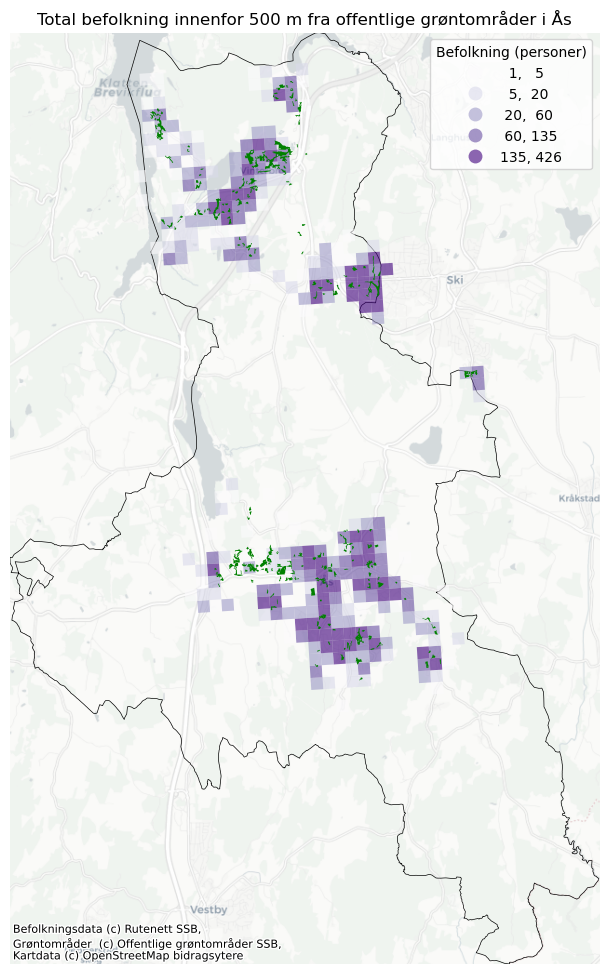

In [10]:
# Befolkningsrutene som er innenfor 500 m fra grøntområdene
innenfor = rutenett.loc[rutenett["nær_grøntareal"] == True].copy()

# Plotter befolkningsruter som er innenfor bufferne fra grøntområdene
ax = innenfor.plot(
    figsize=(12,10), 
    column="pop_tot",
    cmap="Purples",                         
    scheme="quantiles", k=5,                
    legend=True,    
    legend_kwds={
        "title": "Befolkning (personer)",   
        "fmt": "{:.0f}"},
    alpha=0.6,                              
    zorder=2                                
)

# Plotter offentlige grøntområdene i Ås kommune 
grontareal.plot(ax=ax, facecolor="green", zorder=3)

# Plotter grensen for Ås kommune
Aas.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, alpha=1.0, zorder=1)

# Legger til bakgrunnskart og attribusjon i kartet
ctx.add_basemap(
    ax=ax,
    source=ctx.providers.CartoDB.Positron,
    attribution=(
        "Befolkningsdata (c) Rutenett SSB, \n"
        "Grøntområder  (c) Offentlige grøntområder SSB, \n"
        "Kartdata (c) OpenStreetMap bidragsytere"))


# Velger "zoom" i kartet.
minx, miny, maxx, maxy = Aas.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)


ax.set_title("Total befolkning innenfor 500 m fra offentlige grøntområder i Ås")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_MAPPE / "befolkning_grontomrader_500m_Aas.png", dpi=300)
plt.show()

In [7]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!


## Oppgave 2: Visualiser data i et interaktivt kart (5 poeng)

Lag et *interaktivt* tematisk kart ved å bruke ferdighetene du lærte i forelesningen. Du kan bruke Folium, eller en hvilken som helst annen passende Python-pakke - føl deg fri til å eksperimentere).

Kartet skal inneholde mer enn ett lag (fra minst to forskjellige datasett). Vær oppmerksom på klassifisering og visualisering (valg av passende fargeskjema, etc.). Skriv koden din i denne notebooken, og lagre de resulterende kartene i .html-format (pluss muligens tilleggsfiler, avhengig av din tilnærming) i `NOTEBOOK_MAPPE / "output"`-mappen.

### Tema for kartet

- Bruk et hvilket som helst av datasettene vi har brukt i løpet av kurset (f.eks. befolkningsrutenett), eller et hvilket som helst annet datasett av interesse (for eksempel, åpne datasett fra Statistisk sentralbyrå, eller åpne geo-data fra GeoNorge). Hvis du laster ned datasett, legg de til `DATA_MAPPE`. Sørg for å inkludere en attribusjon til hvert datasett i ditt output-kart!
- Føl deg fri til å starte fra og tilpasse eksempler fra kursmaterialet! Du kan ta et skritt videre og legge til ytterligere analyser (f.eks. befolkningen i nærheten av visse adresser)
- Dette skal **ikke** være en interaktiv versjon av din innlevering for oppgave 1! Lag noe nytt!

### Kriterier

- Kartet har mer enn ett datalag (for eksempel resultatene av en analyse og veinettet for å illustrere et komplekst romlig mønster). Hvis (og bare hvis) du mener det tilfører ekstra verdi, kan du gjerne legge til et bakgrunnskart (men et bakgrunnskart teller ikke som et eget lag)
- Kartet viser resultatet av en analyse eller en klassifisering som tilfører verdi utover bare å vise rådataene
- Kartet følger gode kartografiske praksiser (passende kartutstrekning og zoomnivå, fargeskjema, tegnforklaring og datakilder, osv.)
- Kartet demonstrerer ferdighetene lært i forelesningen, interaktive elementer (popups, osv.) er et pluss.

### Output

- Lagre kartet i `.html`-format i `NOTEBOOK_MAPPE / "output"`-mappen
- Husk også å legge til inputdatasett og kode

---

In [11]:
import pathlib
import folium
import shapely
import geopandas as gpd
import pandas as pd

In [12]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

NOTEBOOK_MAPPE = pathlib.Path().resolve()
DATA_MAPPE = NOTEBOOK_MAPPE / "data"
OUTPUT_MAPPE = NOTEBOOK_MAPPE / "output"

In [13]:
# Leser inn data
naturvernsoner = gpd.read_file(DATA_MAPPE / "skjak_naturvern.gdb", layer='Naturvernområde')
turstier = gpd.read_file(DATA_MAPPE / "skjak_tur_og_friluftsruter.gdb", layer='fotrute_senterlinje')
infopunkt = gpd.read_file(DATA_MAPPE / "skjak_tur_og_friluftsruter.gdb", layer='ruteinfopunkt_posisjon')

In [14]:
# Sjekker at inndataen har samme CRS
assert naturvernsoner.crs == turstier.crs == infopunkt.crs, "Inndataene har ikke samme CRS!"

In [15]:
# Finner turstier som går innenfor naturvernsoner
turstier_innenfor = turstier.overlay(naturvernsoner, how='intersection')
turstier_innenfor["status"] = "Innenfor naturvernsone"

# Finner turstier som går utenfor naturvernsoner
turstier_utenfor = turstier.overlay(naturvernsoner, how='difference')
turstier_utenfor["status"] = "Utenfor naturvernsone"

# Slår sammen resultatene med turstier innenfor og utenfor naturvernsoner til en GeoDataFrame
turstier = gpd.GeoDataFrame(pd.concat([turstier_innenfor, turstier_utenfor], ignore_index=True), crs=turstier.crs)

In [16]:
# Velger kolonner jeg ønsker å inkludere i kartet
turstier = turstier[["skilting", "merking", "status", "geometry"]].copy()
infopunkt = infopunkt[["opphav", "informasjon", "geometry"]].copy()

In [17]:
# Sørger for at alle punktene har en beskrivelse av hvor man står
# ut i fra kolonnene 'opphav' og 'informasjon'
infopunkt["popup_tekst"] = (
    infopunkt[["opphav", "informasjon"]]
    .astype("string")         
    .bfill(axis=1)            
    .iloc[:, 0]               
    .fillna("")               
)

# Fjerner infopunkt som ikke har beskrivelse av sted
infopunkt = infopunkt[infopunkt["popup_tekst"].str.len() > 0].copy()
infopunkt = infopunkt[infopunkt["popup_tekst"] != "Rett i kartet"].copy()

In [18]:
# Reprojiserer til EPSG:4326
infopunkt = infopunkt.to_crs(4326)
turstier = turstier.to_crs(4326)
naturvernsoner = naturvernsoner.to_crs(4326)

In [19]:
# Konfigurerer popup-vinduet til punktmarkørene
info_popup = folium.GeoJsonPopup(
        fields=["popup_tekst"],
        aliases=["Du står ved:"],
        localize=True,
        labels=True
    )

# Konfigurerer popup-vinduet til naturvernsone-polygoner
naturvern_popup = folium.GeoJsonPopup(
    fields=["offisieltNavn", "verneform"],
    aliases=["Dette er:", "Verneform:"],
    localize=False,
    labels=True
)

In [20]:
# Oppretter interaktiv kart
interactive_map = folium.Map(
    location=(61.9229, 8.0419),     # Koordinatet til en av punktmarkørene ca i midten av området
    control_scale=True,
    tiles="CartoDB Positron",
)

In [22]:
# Legger til informasjonspunktene i kartet
folium.GeoJson(
    infopunkt.__geo_interface__,
    name="Informasjonspunkt for fotturer i Skjåk",
    marker=folium.Marker(icon=folium.Icon(color="lightblue", icon='info-sign')),

    tooltip=folium.GeoJsonTooltip(
        fields=["popup_tekst"],
        aliases=["Sted:"],
        sticky=True
    ),
    popup=info_popup,
    zoom_on_click=False,
).add_to(interactive_map)

In [23]:
# Gjør naturvernsoner klar til å plottes i kartet
naturvernsoner["cddaId"] = naturvernsoner.index.astype(str)

# Legger til naturvernsone polygoner i kartet
folium.GeoJson(
    naturvernsoner.__geo_interface__,
    name="Naturvernområder i Skjåk",
    popup=naturvern_popup,
    zoom_on_click=False,
    
    style_function=lambda feature: {
        "fillColor": "#A1957A",
        "color": "#584D30",
        "weight": 2,
        "dashArray": "3, 5",
        "fillOpacity": 0.25
    },
    highlight_function=lambda feature: {
        "fillColor": "#d1cc9c",
        "color": "#968b6c",
        "weight": 3,
        "fillOpacity": 0.45
    },
    popup_keep_highlighted=True
).add_to(interactive_map)

In [24]:
# Legger til turstiene i kartet
folium.GeoJson(
    turstier.__geo_interface__,
    name="Turstier i Skjåk",

    tooltip=folium.GeoJsonTooltip(
        fields=["status", "skilting", "merking"],
        aliases=["Status:", "Er stien skiltet:", "Er stien merket:"],
        sticky=True
    ),
    popup=None,
    zoom_on_click=False,
    highlight_function=None,
    style_function=lambda feature: {
        "color": "#1b6fa9"
        if feature["properties"].get("status") == "Innenfor naturvernsone"
        else "#2d8f0c",
        "weight": 2,
    },
).add_to(interactive_map)

In [25]:
# Legger til panel for å skru av/på datalag
folium.LayerControl(collapsed=False).add_to(interactive_map)

# Setter det innledende zoomnivået på kartet
layers = gpd.GeoDataFrame(pd.concat([turstier, naturvernsoner], ignore_index=True), crs=turstier.crs)
minx, miny, maxx, maxy = layers.total_bounds
folium.FitBounds([[miny, minx], [maxy, maxx]]).add_to(interactive_map)

In [26]:
interactive_map

In [27]:
interactive_map.save(OUTPUT_MAPPE / "turstier_naturvernsoner_Skjak.html") 

In [28]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
